In [20]:
import cascade.roadway_manager
import numpy as np
#loading CASCADE simulations
data = np.load ('/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/OCR_IL_Status_Quo_S0_Accretional_Sink.npz', allow_pickle=True )
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/OCR_IL_Status_Quo_S0_Accretional_Sink.npz' with keys: cascade

In [21]:
cascade_object = data['cascade'][0]

In [22]:
roadways_domain = cascade_object.roadways[45]._road_ele_TS
len(roadways_domain)

126

In [23]:
import pandas as pd
Daily_WL_MHW = pd.read_csv('/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/Daily_WL_MHW.csv')
Daily_WL_NAVD = pd.read_csv('/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/Daily_WL_NAVD.csv')

In [24]:
Daily_WL_MHW['t'] = pd.to_datetime(Daily_WL_MHW['t'])
Daily_WL_NAVD['t'] = pd.to_datetime(Daily_WL_NAVD['t'])

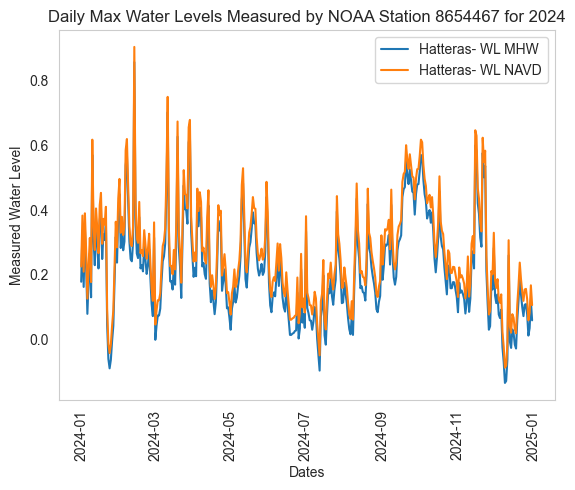

In [25]:
import matplotlib.pyplot as plt 
plt.plot(Daily_WL_MHW['t'], Daily_WL_MHW['v'], label= 'Hatteras- WL MHW')
plt.plot(Daily_WL_NAVD['t'], Daily_WL_NAVD['v'], label= 'Hatteras- WL NAVD')

plt.xlabel('Dates')  # Rotates the label vertically
plt.ylabel('Measured Water Level')
plt.title('Daily Max Water Levels Measured by NOAA Station 8654467 for 2024')
plt.grid()
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [26]:
# yesrs of interest
target_years = [25, 50, 75, 100]
# Check if the roadways is not empty
if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    # Loop through each target year
    for year in target_years:
        print(f"\n Data for Year {year}: ")    
        # Loop through each domain (roadway segment)
        for i, road_segment in enumerate(cascade_object.roadways):
            
            # Access the time series for the current road segment
            elevation_time_series = road_segment._road_ele_TS
            elevation = elevation_time_series[year]
            print(f"Domain {i}: Road Elevation = {elevation}")


 Data for Year 25: 
Domain 0: Road Elevation = 0.0
Domain 1: Road Elevation = 0.0
Domain 2: Road Elevation = 0.0
Domain 3: Road Elevation = 0.0
Domain 4: Road Elevation = 0.0
Domain 5: Road Elevation = 0.0
Domain 6: Road Elevation = 0.0
Domain 7: Road Elevation = 0.0
Domain 8: Road Elevation = 0.0
Domain 9: Road Elevation = 0.0
Domain 10: Road Elevation = 0.0
Domain 11: Road Elevation = 0.0
Domain 12: Road Elevation = 0.0
Domain 13: Road Elevation = 0.0
Domain 14: Road Elevation = 0.0
Domain 15: Road Elevation = 1.2741423971163375
Domain 16: Road Elevation = 1.2741423971163375
Domain 17: Road Elevation = 1.2741423971163375
Domain 18: Road Elevation = 1.2741423971163375
Domain 19: Road Elevation = 1.2741423971163375
Domain 20: Road Elevation = 1.2741423971163375
Domain 21: Road Elevation = 1.2741423971163375
Domain 22: Road Elevation = 1.2741423971163375
Domain 23: Road Elevation = 1.2741423971163375
Domain 24: Road Elevation = 1.2741423971163375
Domain 25: Road Elevation = 1.274142397

In [27]:
#exporting road elevations for aech domain categorized by the years

results_list = []
target_years = [25, 50, 75, 100]

if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            elevation_time_series = road_segment._road_ele_TS
            
            if year < len(elevation_time_series):
                elevation = elevation_time_series[year]
                
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation': elevation
                }
                results_list.append(result_row)
                
            else:
                print(f"Data for Year {year}, Domain {i} is not available.")

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    results_df = pd.DataFrame(results_list)
    output_filename = 'road_elevations_by_year.csv'

    results_df.to_csv(output_filename, index=False)
    print(results_df.head()) 


   Year  Domain  Road_Elevation
0    25       0             0.0
1    25       1             0.0
2    25       2             0.0
3    25       3             0.0
4    25       4             0.0


In [28]:
#load the csv files for road elvation and water level
road_elevation = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/road_elevations_by_year.csv'
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/Daily_WL_NAVD.csv'
road_df = pd.read_csv(road_elevation)
water_df = pd.read_csv(water_level_NAVD)


In [29]:
#daily max water level (NAVD)
daily_tidal_levels = water_df['v'].values
daily_tidal_levels

array([ 0.225,  0.382,  0.209,  0.389,  0.274,  0.126,  0.23 ,  0.313,
        0.177,  0.616,  0.355,  0.276,  0.404,  0.344,  0.266,  0.414,
        0.452,  0.295,  0.372,  0.354,  0.409,  0.093, -0.013, -0.042,
       -0.016,  0.042,  0.089,  0.228,  0.363,  0.284,  0.435,  0.495,
        0.329,  0.378,  0.322,  0.349,  0.584,  0.618,  0.475,  0.35 ,
        0.295,  0.288,  0.348,  0.902,  0.421,  0.312,  0.298,  0.424,
        0.266,  0.276,  0.257,  0.337,  0.291,  0.249,  0.276,  0.326,
        0.237,  0.157,  0.119,  0.361,  0.046,  0.09 ,  0.121,  0.121,
        0.142,  0.224,  0.288,  0.303,  0.343,  0.508,  0.748,  0.34 ,
        0.226,  0.227,  0.201,  0.276,  0.216,  0.365,  0.672,  0.331,
        0.271,  0.175,  0.343,  0.522,  0.449,  0.445,  0.404,  0.654,
        0.677,  0.379,  0.305,  0.24 ,  0.268,  0.242,  0.465,  0.396,
        0.454,  0.424,  0.272,  0.283,  0.248,  0.234,  0.379,  0.46 ,
        0.22 ,  0.162,  0.198,  0.167,  0.125,  0.162,  0.269,  0.414,
      

In [30]:
#comparing road elevations only with tidal water levels
for index, road_row in road_df.iterrows():
        
        # Get the specific data from the current row
        year = int(road_row['Year'])
        domain = int(road_row['Domain'])
        road_elevation = road_row['Road_Elevation']
        
        # compare directly against the single array of 365 daily levels.
        is_flooded = road_elevation < daily_tidal_levels
        
        # Count how many days the road was flooded
        flooded_days_count = np.sum(is_flooded)
        
        total_days_in_data = len(daily_tidal_levels)
        
        print(f"Year {year}, Domain {domain} (Road Elev: {road_elevation:.2f}m): Flooded on {flooded_days_count} out of {total_days_in_data} days.")


Year 25, Domain 0 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 1 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 2 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 3 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 4 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 5 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 6 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 7 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 8 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 9 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 10 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 11 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 12 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 13 (Road Elev: 0.00m): Flooded on 357 out of 366 days.
Year 25, Domain 

Here, I was trying to find out SLR values in the model, then I remembered Benton sent them to us, so I used them instead!!

In [31]:
# looking into SLR values in the model
slr_rate = cascade_object._sea_level_rise_rate
is_slr_constant = cascade_object._slr_constant

print(f"Sea-Level Rise Rate (_sea_level_rise_rate): {slr_rate} m/yr")
print(f"Is Sea-Level Rise Constant? (_slr_constant): {is_slr_constant}")

Sea-Level Rise Rate (_sea_level_rise_rate): 0.0056 m/yr
Is Sea-Level Rise Constant? (_slr_constant): True


In [32]:
#RSLR investigation
results_list = []
target_years = [25, 50, 75, 100]

if not cascade_object.barrier3d:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, domainsl in enumerate(cascade_object.barrier3d):
            slr_series = domainsl.RSLR
            
            if year < len(slr_series):
                slr_series = slr_series[year]
                
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'slr': slr_series
                }
                results_list.append(result_row)

if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    results_df = pd.DataFrame(results_list)

    output_filename = 'slr_by_year.csv'

    results_df.to_csv(output_filename, index=False)
    
    print(f"\nSuccessfully exported data to '{output_filename}'")
    print(results_df.head()) 


Successfully exported data to 'slr_by_year.csv'
   Year  Domain       slr
0    25       0  0.000767
1    25       1  0.000767
2    25       2  0.000767
3    25       3  0.000767
4    25       4  0.000767



 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to 'final_flooding_analysis_by_scenario.csv'

 *** Generating Heatmaps ***
Generating heatmap for scenario: 'IL'...
  > Plot saved as 'heatmap_scenario_IL.png'


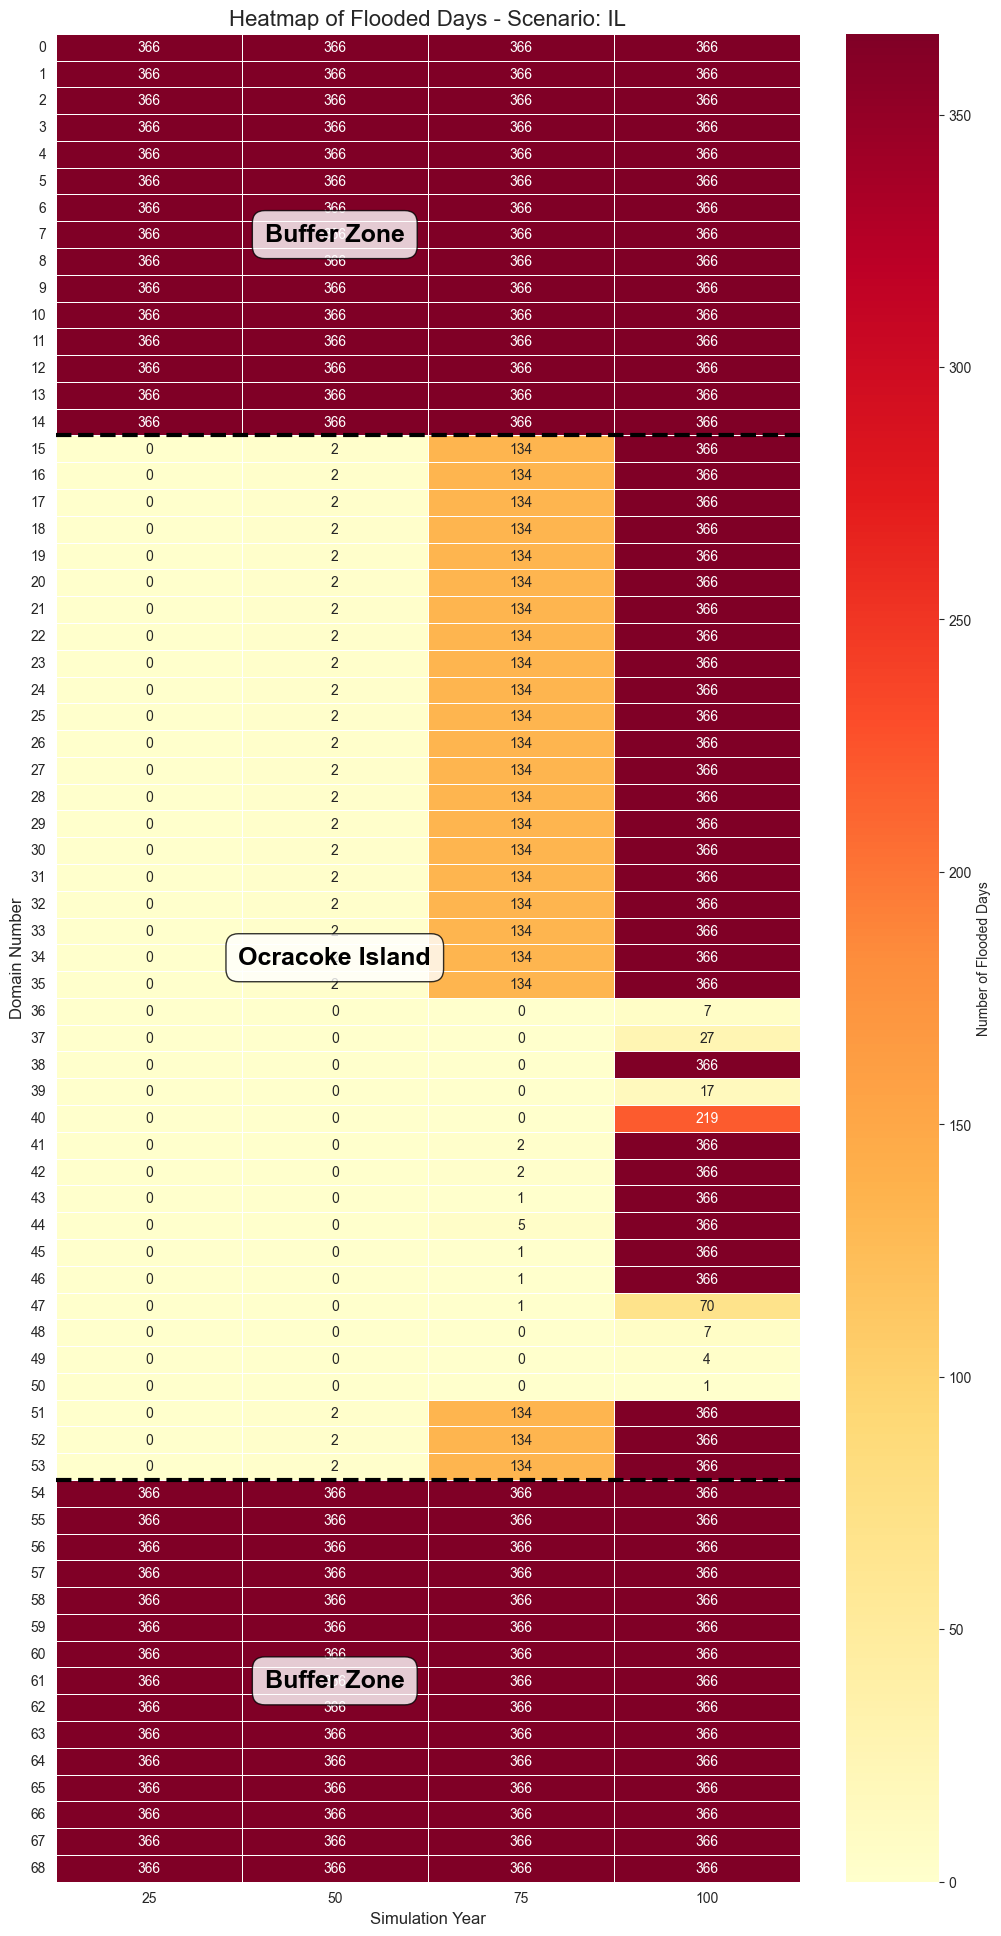

Generating heatmap for scenario: 'I'...
  > Plot saved as 'heatmap_scenario_I.png'


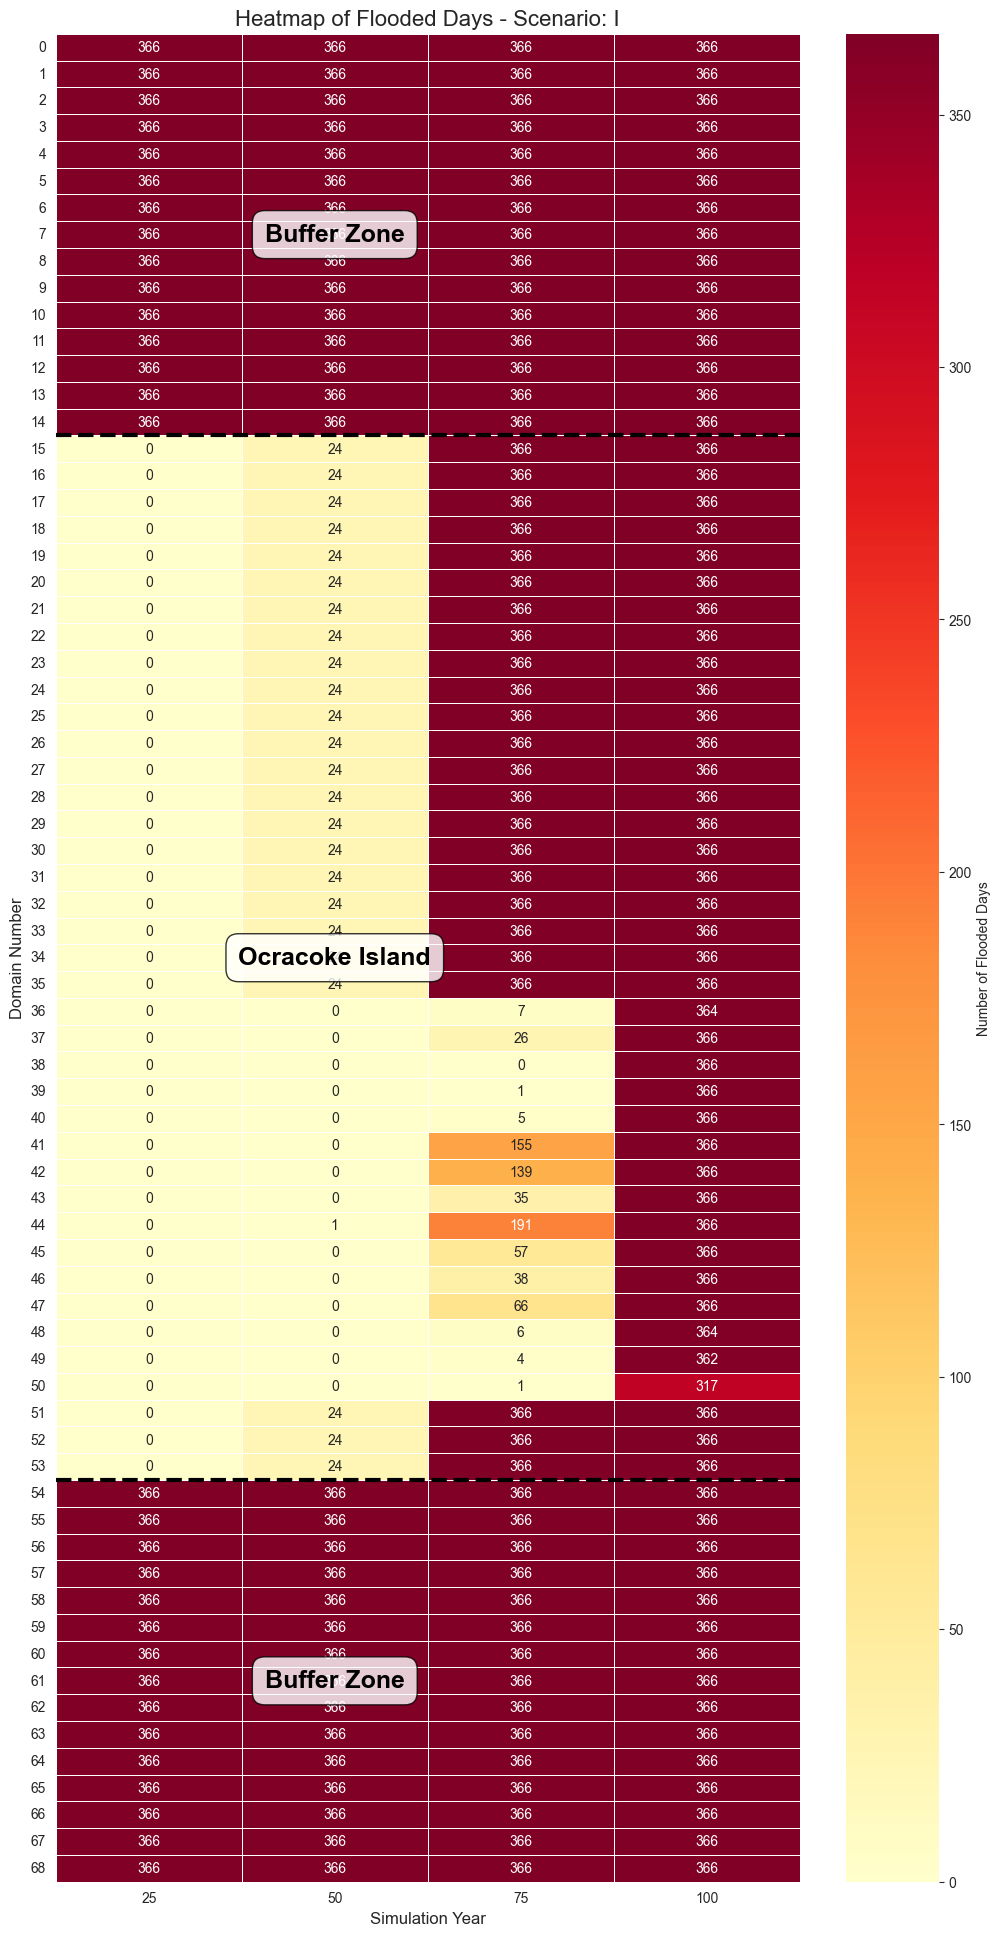

Generating heatmap for scenario: 'IH'...
  > Plot saved as 'heatmap_scenario_IH.png'


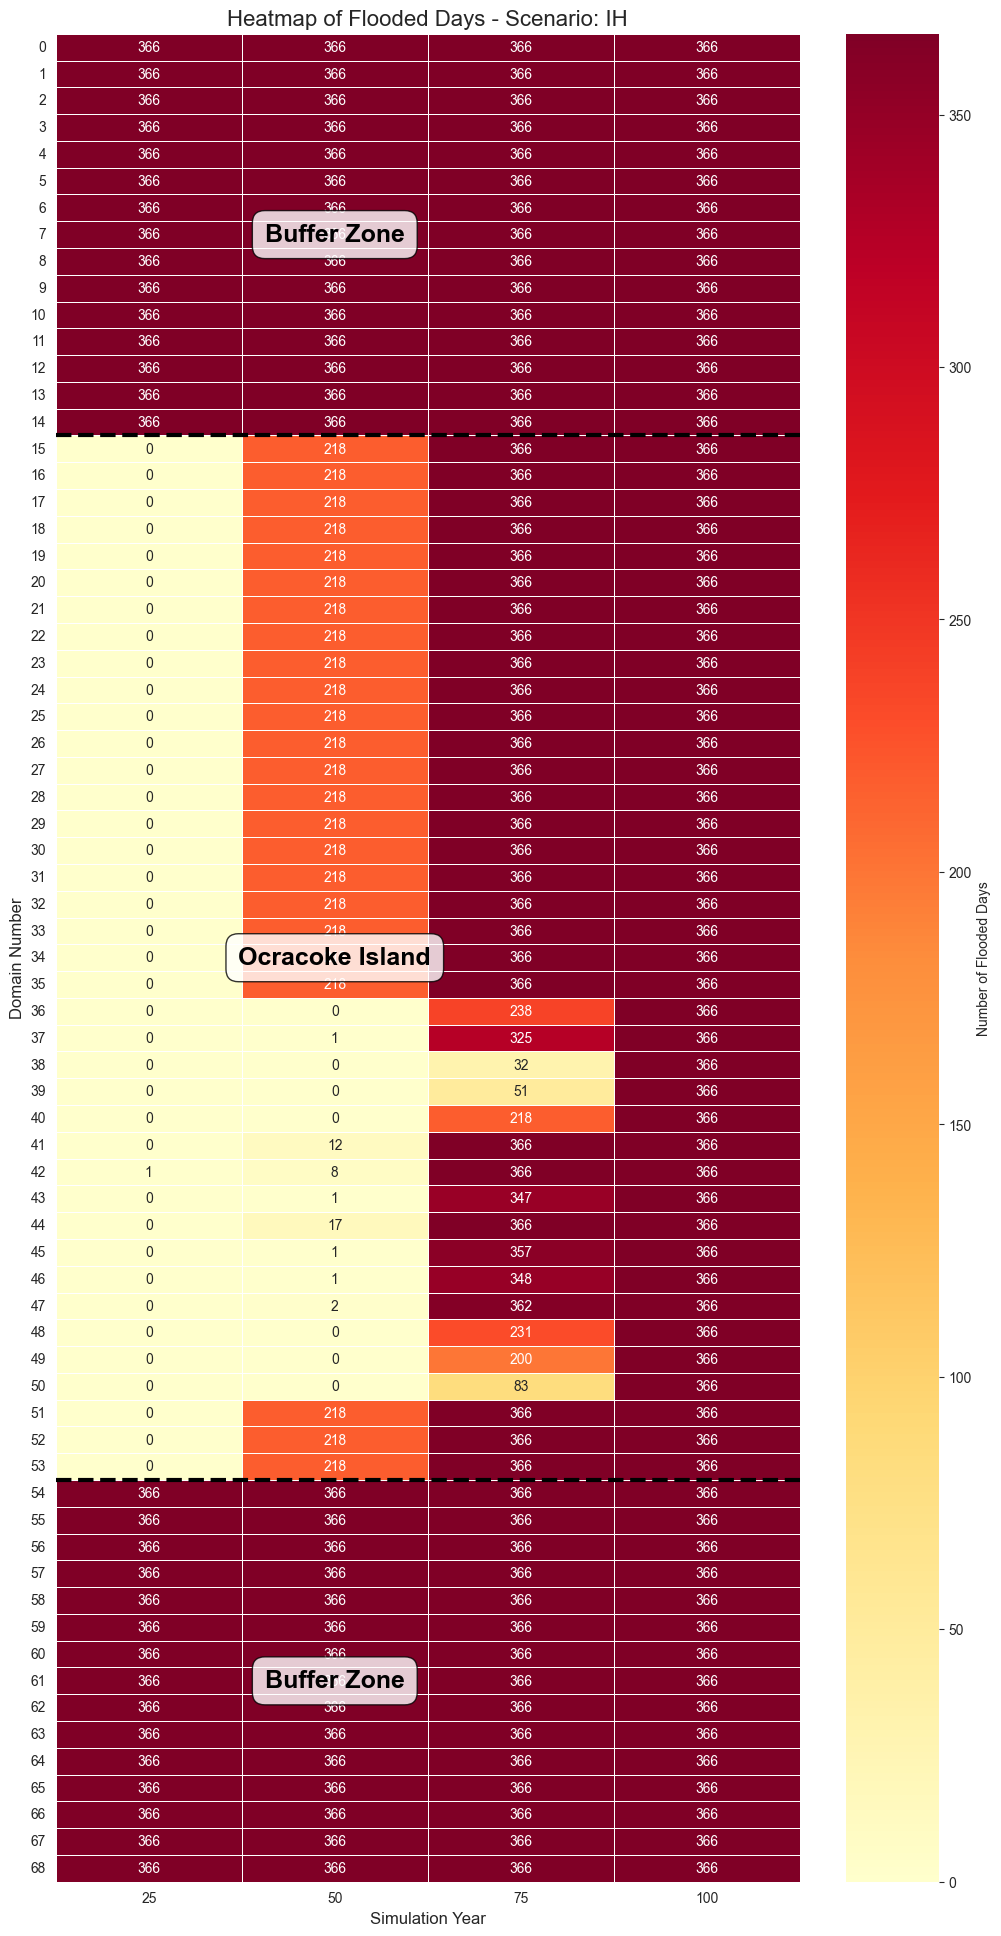

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#read the road elev and tidal water levels and specify a file name to output
road_elevation_filepath = 'road_elevations_by_year.csv'
tidal_water_level_filepath = 'Daily_WL_NAVD.csv'
analysis_output_filepath = 'final_flooding_analysis_by_scenario.csv'

print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None

road_df = pd.read_csv(road_elevation_filepath)
tidal_df = pd.read_csv(tidal_water_level_filepath, skiprows=1, header=None)
print("Successfully loaded all input files (skipped header in water level file).")

# Create a DataFrame from the SLR senarios data from Benton
slr_data = {
    'Year': [25, 50, 75, 100],
    'IL': [0.17, 0.37, 0.57, 0.78],
    'I': [0.21, 0.55, 0.98, 1.47],
    'IH': [0.35, 0.86, 1.41, 1.98]
}
slr_df = pd.DataFrame(slr_data).set_index('Year')

# # Clean the water level data
# water_level_column = tidal_df.columns[1] # WL values
# tidal_df[water_level_column] = pd.to_numeric(tidal_df[water_level_column], errors='coerce')
# tidal_df.dropna(subset=[water_level_column], inplace=True)
# daily_tidal_levels = tidal_df[water_level_column].values
# print(f"Successfully cleaned data from '{tidal_water_level_filepath}'.")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation']
    
    for scenario in slr_df.columns:
        slr_value = slr_df.loc[year, scenario]
        total_water_levels = daily_tidal_levels + slr_value
        flooded_days = np.sum(road_elevation < total_water_levels)
        
        result_row = {
            'Year': year,
            'Domain': domain,
            'Scenario': scenario,
            'SLR_m': slr_value,
            'Road_Elevation_m': road_elevation,
            'Flooded_Days': flooded_days,
        }
        final_results.append(result_row)

# Save the analysis results to a CSV file

results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")

# --- Create a Heatmap for Each Scenario from the Generated Data ---
print("\n *** Generating Heatmaps ***")
scenarios = results_df['Scenario'].unique()

for scenario in scenarios:
    print(f"Generating heatmap for scenario: '{scenario}'...")

    scenario_df = results_df[results_df['Scenario'] == scenario]
    heatmap_data = scenario_df.pivot_table(index='Domain', columns='Year', values='Flooded_Days')

    plt.figure(figsize=(12, 24))
    sns.set_style("whitegrid")
    ax = sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Number of Flooded Days'})

    ax.axhline(y=15, color='black', linestyle='--', linewidth=3)
    ax.axhline(y=54, color='black', linestyle='--', linewidth=3)

    text_props = dict(ha='center', va='center', fontsize=18, color='black', weight='bold')
    bbox_props = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1, alpha=0.8)

    plt.text(1.5, 7.5, 'Buffer Zone', **text_props, bbox=bbox_props)
    plt.text(1.5, 34.5, 'Ocracoke Island', **text_props, bbox=bbox_props)
    plt.text(1.5, 61.5, 'Buffer Zone', **text_props, bbox=bbox_props)

    plt.title(f'Heatmap of Flooded Days - Scenario: {scenario}', fontsize=16)
    plt.xlabel('Simulation Year', fontsize=12)
    plt.ylabel('Domain Number', fontsize=12)
    plt.yticks(rotation=0)

    plot_output_filename = f'heatmap_scenario_{scenario}.png'
    plt.savefig(plot_output_filename, bbox_inches='tight')
    print(f"  > Plot saved as '{plot_output_filename}'")
    plt.show() # Close the figure to avoid displaying multiple plots at once


In [34]:
total_water_levels

array([2.205, 2.362, 2.189, 2.369, 2.254, 2.106, 2.21 , 2.293, 2.157,
       2.596, 2.335, 2.256, 2.384, 2.324, 2.246, 2.394, 2.432, 2.275,
       2.352, 2.334, 2.389, 2.073, 1.967, 1.938, 1.964, 2.022, 2.069,
       2.208, 2.343, 2.264, 2.415, 2.475, 2.309, 2.358, 2.302, 2.329,
       2.564, 2.598, 2.455, 2.33 , 2.275, 2.268, 2.328, 2.882, 2.401,
       2.292, 2.278, 2.404, 2.246, 2.256, 2.237, 2.317, 2.271, 2.229,
       2.256, 2.306, 2.217, 2.137, 2.099, 2.341, 2.026, 2.07 , 2.101,
       2.101, 2.122, 2.204, 2.268, 2.283, 2.323, 2.488, 2.728, 2.32 ,
       2.206, 2.207, 2.181, 2.256, 2.196, 2.345, 2.652, 2.311, 2.251,
       2.155, 2.323, 2.502, 2.429, 2.425, 2.384, 2.634, 2.657, 2.359,
       2.285, 2.22 , 2.248, 2.222, 2.445, 2.376, 2.434, 2.404, 2.252,
       2.263, 2.228, 2.214, 2.359, 2.44 , 2.2  , 2.142, 2.178, 2.147,
       2.105, 2.142, 2.249, 2.394, 2.363, 2.377, 2.177, 2.208, 2.243,
       2.194, 2.123, 2.126, 2.094, 2.057, 2.122, 2.143, 2.196, 2.141,
       2.156, 2.192,